In [2]:
from google.colab import files
uploaded = files.upload()

Saving market_predictor (2).zip to market_predictor (2).zip


In [3]:
import zipfile, os

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/project')

os.chdir('/content/project')
contents = os.listdir('.')
if len(contents) == 1 and os.path.isdir(contents[0]):
    os.chdir(contents[0])
print('Working dir:', os.getcwd())
print(os.listdir('.'))

Working dir: /content/project/market_predictor
['labeling.py', 'data_fetch.py', 'predict.py', 'data', 'sentiment.py', '__pycache__', 'web_scraper.py', 'build_dataset.py', 'requirements.txt', 'news_scrape.py', 'models', 'config.py', 'README.md', 'feature_engineering.py', 'ner_extract.py', 'train_model.py']


In [4]:
!pip install -q -r requirements.txt

In [5]:
!python data_fetch.py

Fetching AAPL from 2024-09-26 to 2026-09-26 ...
Fetching TSLA from 2024-09-26 to 2026-09-26 ...
Fetching MSFT from 2024-09-26 to 2026-09-26 ...
Fetching GOOGL from 2024-09-26 to 2026-09-26 ...
Fetching AMZN from 2024-09-26 to 2026-09-26 ...
Fetching NVDA from 2024-09-26 to 2026-09-26 ...

Saved 3006 rows for 6 tickers -> data/raw/market_data.csv
        count        min        max
Ticker                             
AAPL      501 2024-09-26 2026-09-25
AMZN      501 2024-09-26 2026-09-25
GOOGL     501 2024-09-26 2026-09-25
MSFT      501 2024-09-26 2026-09-25
NVDA      501 2024-09-26 2026-09-25
TSLA      501 2024-09-26 2026-09-25


In [6]:
!python feature_engineering.py

Saved features for 3006 rows -> data/features/features.csv
           Date Ticker        Open  ...  volume_ratio  prev_close   gap_pct
3001 2026-09-21   TSLA  371.640015  ...      1.000313  364.269989  0.020232
3002 2026-09-22   TSLA  379.070007  ...      0.822951  375.299988  0.010045
3003 2026-09-23   TSLA  380.100006  ...      0.974517  378.899994  0.003167
3004 2026-09-24   TSLA  377.350006  ...      0.768473  380.119995 -0.007287
3005 2026-09-25   TSLA  384.619995  ...      1.289094  377.940002  0.017675

[5 rows x 17 columns]


In [7]:
!python labeling.py

Saved 3000 labeled rows -> data/features/labeled_features.csv

Label distribution:
target
neutral    1765
spike       668
crash       567
Name: count, dtype: int64


In [9]:
!python news_scrape.py

Fetching yfinance news for AAPL ...
Fetching yfinance news for TSLA ...
Fetching yfinance news for MSFT ...
Fetching yfinance news for GOOGL ...
Fetching yfinance news for AMZN ...
Fetching yfinance news for NVDA ...
Scraping Google News for Apple (AAPL) ...
Scraping Google News for Tesla (TSLA) ...
Scraping Google News for Microsoft (MSFT) ...
Scraping Google News for Google (GOOGL) ...
Scraping Google News for Amazon (AMZN) ...
Scraping Google News for Nvidia (NVDA) ...

Saved 522 total headlines (179 new this run) -> data/news/news_history.csv
By source:
Source
google_news    341
yfinance       181
Name: count, dtype: int64
           Date  ...       Source
512  2026-09-25  ...  google_news
513  2026-09-25  ...  google_news
514  2026-09-25  ...  google_news
515  2026-09-25  ...  google_news
516  2026-09-26  ...     yfinance
517  2026-09-26  ...     yfinance
518  2026-09-26  ...     yfinance
519  2026-09-26  ...     yfinance
520  2026-09-26  ...     yfinance
521  2026-09-26  ...  goo

In [10]:
!python build_dataset.py

Saved 3000 rows -> data/features/labeled_features_with_news.csv
21 of 3000 rows have real scraped news coverage (0.7%).
           Date Ticker  news_sentiment_mean  news_count   target
2990 2026-09-11   TSLA             0.000000           0    crash
2991 2026-09-14   TSLA             0.000000           0  neutral
2992 2026-09-15   TSLA             0.000000           0  neutral
2993 2026-09-16   TSLA             0.000000           0    spike
2994 2026-09-17   TSLA             0.000000           0  neutral
2995 2026-09-18   TSLA             0.000000           0    spike
2996 2026-09-21   TSLA             0.250000           4  neutral
2997 2026-09-22   TSLA            -0.200000           5  neutral
2998 2026-09-23   TSLA             0.136364          22  neutral
2999 2026-09-24   TSLA             0.000000          25    crash


In [11]:
!python build_dataset.py

Saved 3000 rows -> data/features/labeled_features_with_news.csv
21 of 3000 rows have real scraped news coverage (0.7%).
           Date Ticker  news_sentiment_mean  news_count   target
2990 2026-09-11   TSLA             0.000000           0    crash
2991 2026-09-14   TSLA             0.000000           0  neutral
2992 2026-09-15   TSLA             0.000000           0  neutral
2993 2026-09-16   TSLA             0.000000           0    spike
2994 2026-09-17   TSLA             0.000000           0  neutral
2995 2026-09-18   TSLA             0.000000           0    spike
2996 2026-09-21   TSLA             0.250000           4  neutral
2997 2026-09-22   TSLA            -0.200000           5  neutral
2998 2026-09-23   TSLA             0.136364          22  neutral
2999 2026-09-24   TSLA             0.000000          25    crash


In [12]:
!python train_model.py

Using combined price+news dataset -> data/features/labeled_features_with_news.csv

=== Classification report (test set) ===
              precision    recall  f1-score   support

       crash       0.22      0.19      0.20       111
     neutral       0.70      0.70      0.70       346
       spike       0.25      0.28      0.26       131

    accuracy                           0.51       588
   macro avg       0.39      0.39      0.39       588
weighted avg       0.51      0.51      0.51       588

Macro F1: 0.38986597215569013

Confusion matrix (rows=true, cols=pred), labels = ['crash', 'neutral', 'spike']
[[ 21  42  48]
 [ 40 242  64]
 [ 33  61  37]]

=== Feature importances ===
  hl_range_pct         0.1727
  volatility           0.1667
  gap_pct              0.1134
  volume_ratio         0.1120
  return_1d            0.1115
  return_5d            0.1096
  return_3d            0.1096
  return_10d           0.1044
  news_count           0.0000
  news_sentiment_mean  0.0000

Saved mo

In [13]:
!python predict.py


=== Prediction ===
title: Tesla shares jump on record deliveries
ticker: TSLA
as_of_date: 2026-09-25
model_prediction: crash
model_probabilities: {'crash': np.float64(0.376), 'neutral': np.float64(0.292), 'spike': np.float64(0.332)}
headline_sentiment_score: 1.0
final_prediction: spike
final_probabilities: {'crash': np.float64(0.244), 'neutral': np.float64(0.19), 'spike': np.float64(0.566)}
recent_news_used: {'news_sentiment_mean': np.float64(0.035), 'news_count': 86}


In [14]:
!python predict.py --headline "Apple announces record iPhone sales" --ticker AAPL


=== Prediction ===
title: --headline Apple announces record iPhone sales --ticker AAPL
ticker: AAPL
as_of_date: 2026-09-25
model_prediction: neutral
model_probabilities: {'crash': np.float64(0.252), 'neutral': np.float64(0.536), 'spike': np.float64(0.212)}
headline_sentiment_score: 1.0
final_prediction: spike
final_probabilities: {'crash': np.float64(0.164), 'neutral': np.float64(0.348), 'spike': np.float64(0.488)}
recent_news_used: {'news_sentiment_mean': np.float64(0.034), 'news_count': 88}


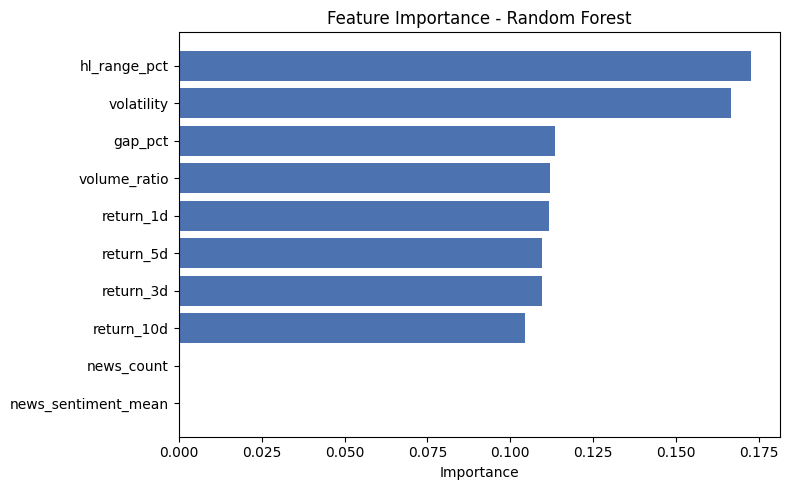

In [15]:
import joblib, matplotlib.pyplot as plt
import config

model = joblib.load(config.MODEL_PATH)
feature_columns = joblib.load("models/features_used.joblib")

importances = sorted(zip(feature_columns, model.feature_importances_), key=lambda x: -x[1])
names = [n for n, _ in importances]
vals = [v for _, v in importances]

plt.figure(figsize=(8,5))
plt.barh(names[::-1], vals[::-1], color="#4C72B0")
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

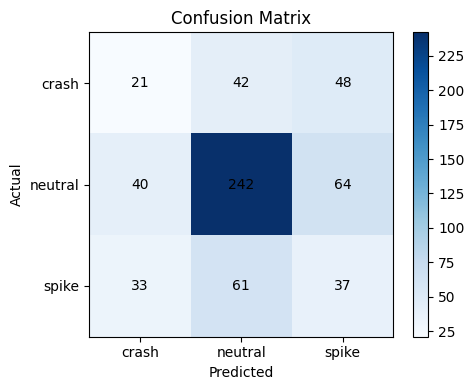

In [16]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("data/features/labeled_features_with_news.csv", parse_dates=["Date"])
df = df.dropna(subset=feature_columns + ["target"])
X = df[feature_columns]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
)
scaler = joblib.load(config.SCALER_PATH)
X_test_scaled = scaler.transform(X_test)
preds = model.predict(X_test_scaled)

labels = sorted(y.unique())
cm = confusion_matrix(y_test, preds, labels=labels)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [17]:
import shutil
shutil.make_archive('/content/market_predictor_results', 'zip', '.')
from google.colab import files
files.download('/content/market_predictor_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>